# Wind Power Reliability Analysis

How many MW of wind power can we **reliably** expect to meet electricity demand?  
Analysis of actual UK wind generation data from Elexon BMRS (Jan 2025 onwards).  
Code cells only — interpretation and recommendation cells are left for analyst input.

In [1]:
# ============================================================
# SETUP — Libraries, Constants, Data Fetching
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import requests
from datetime import datetime, timezone
import os
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

# ── Constants ────────────────────────────────────────────────
FUELHH_URL = 'https://data.elexon.co.uk/bmrs/api/v1/datasets/FUELHH/stream'
FUEL_TYPE_FILTER = 'WIND'

DATA_START = '2025-01-01T00:00:00Z'
DATA_END = datetime.now(timezone.utc).strftime('%Y-%m-%dT%H:%M:%SZ')

EXPECTED_RESOLUTION_MIN = 30  # Half-hourly data

FIGURE_DIR = 'figures/reliability'
FIGURE_SIZE = (12, 5)
HIST_BINS = 100

# Colour palette
C_ACTUAL = '#3b82f6'    # Blue for actuals
C_FORECAST = '#22c55e'  # Green for forecasts
C_LOW_WIND = '#ef4444'  # Red for low-wind events
C_BAND = '#93c5fd'      # Light blue for P10-P90 bands

os.makedirs(FIGURE_DIR, exist_ok=True)
print(f'Date range: {DATA_START} → {DATA_END}')

Date range: 2025-01-01T00:00:00Z → 2026-03-19T07:56:53Z


In [2]:
# ── Fetch data in chunks ─────────────────────────────────────

def fetch_chunks(url: str, start: str, end: str, chunk_days: int = 7) -> list:
    """Fetch data from Elexon API in time-windowed chunks."""
    all_data = []
    current = pd.Timestamp(start, tz='UTC')
    end_ts = pd.Timestamp(end, tz='UTC')
    
    while current < end_ts:
        chunk_end = min(current + pd.Timedelta(days=chunk_days), end_ts)
        params = {
            'publishDateTimeFrom': current.isoformat(),
            'publishDateTimeTo': chunk_end.isoformat(),
        }
        resp = requests.get(url, params=params, headers={'Accept': 'application/json'}, timeout=60)
        resp.raise_for_status()
        data = resp.json()
        all_data.extend(data)
        print(f'  Fetched {len(data):,} records for {current.date()} → {chunk_end.date()}')
        current = chunk_end
    
    return all_data

# ── Fetch all WIND actuals ───────────────────────────────────

print('Fetching FUELHH (WIND actuals)...')
raw = fetch_chunks(FUELHH_URL, DATA_START, DATA_END)
df_raw = pd.DataFrame(raw)
print(f'Total raw records: {len(df_raw):,}')

Fetching FUELHH (WIND actuals)...
  Fetched 6,740 records for 2025-01-01 → 2025-01-08
  Fetched 6,740 records for 2025-01-08 → 2025-01-15
  Fetched 6,740 records for 2025-01-15 → 2025-01-22
  Fetched 6,740 records for 2025-01-22 → 2025-01-29
  Fetched 6,740 records for 2025-01-29 → 2025-02-05
  Fetched 6,740 records for 2025-02-05 → 2025-02-12
  Fetched 6,740 records for 2025-02-12 → 2025-02-19
  Fetched 6,740 records for 2025-02-19 → 2025-02-26
  Fetched 6,740 records for 2025-02-26 → 2025-03-05
  Fetched 6,740 records for 2025-03-05 → 2025-03-12
  Fetched 6,740 records for 2025-03-12 → 2025-03-19
  Fetched 6,740 records for 2025-03-19 → 2025-03-26
  Fetched 6,740 records for 2025-03-26 → 2025-04-02
  Fetched 6,740 records for 2025-04-02 → 2025-04-09
  Fetched 6,740 records for 2025-04-09 → 2025-04-16
  Fetched 6,740 records for 2025-04-16 → 2025-04-23
  Fetched 6,740 records for 2025-04-23 → 2025-04-30
  Fetched 6,740 records for 2025-04-30 → 2025-05-07
  Fetched 6,740 records for 20

In [3]:
# ── Parse and clean ──────────────────────────────────────────

df = df_raw[df_raw['fuelType'] == FUEL_TYPE_FILTER].copy()
df['startTime'] = pd.to_datetime(df['startTime'], utc=True)
df['publishTime'] = pd.to_datetime(df['publishTime'], utc=True)

# Deduplicate: keep latest publishTime per startTime
df = (
    df
    .sort_values('publishTime')
    .drop_duplicates(subset='startTime', keep='last')
    .rename(columns={'generation': 'actual'})
    [['startTime', 'actual']]
    .sort_values('startTime')
    .reset_index(drop=True)
)

print(f'Wind generation records: {len(df):,}')
print(f'Range: {df["startTime"].min()} → {df["startTime"].max()}')

# ── Verify resolution and flag gaps ──────────────────────────
time_diffs = df['startTime'].diff().dt.total_seconds() / 60  # in minutes
expected_diffs = time_diffs.dropna()

gaps = expected_diffs[expected_diffs > EXPECTED_RESOLUTION_MIN * 1.5]
print(f'\nExpected resolution: {EXPECTED_RESOLUTION_MIN} min')
print(f'Median resolution: {expected_diffs.median():.0f} min')
print(f'Data gaps found: {len(gaps)}')
if len(gaps) > 0:
    print('\nGap locations (showing gap duration in minutes):')
    for idx in gaps.index[:10]:  # Show up to 10 gaps
        print(f'  {df.loc[idx-1, "startTime"]} → {df.loc[idx, "startTime"]} ({gaps[idx]:.0f} min)')
    if len(gaps) > 10:
        print(f'  ... and {len(gaps) - 10} more')

df.head()

Wind generation records: 21,232
Range: 2024-12-31 23:30:00+00:00 → 2026-03-19 07:00:00+00:00

Expected resolution: 30 min
Median resolution: 30 min
Data gaps found: 0


,startTime,actual
0,2024-12-31 23:30:00+00:00,15522
1,2025-01-01 00:00:00+00:00,15799
2,2025-01-01 00:30:00+00:00,15317
3,2025-01-01 01:00:00+00:00,14992
4,2025-01-01 01:30:00+00:00,14580


---
## Section 1 — Basic Statistics

In [4]:
# ── 1a: Descriptive statistics ───────────────────────────────

stats = {
    'Mean': df['actual'].mean(),
    'Median (P50)': df['actual'].median(),
    'Std Dev': df['actual'].std(),
    'Min': df['actual'].min(),
    'Max': df['actual'].max(),
    'P10': df['actual'].quantile(0.10),
    'P25': df['actual'].quantile(0.25),
    'P50': df['actual'].quantile(0.50),
    'P75': df['actual'].quantile(0.75),
    'P90': df['actual'].quantile(0.90),
}

stats_df = pd.DataFrame({
    'Statistic': stats.keys(),
    'Value (MW)': [f'{v:,.0f}' for v in stats.values()]
})

print('=== Wind Generation — Basic Statistics ===')
print(stats_df.to_string(index=False))

=== Wind Generation — Basic Statistics ===
   Statistic Value (MW)
        Mean      8,409
Median (P50)      8,001
     Std Dev      4,501
         Min          0
         Max     18,439
         P10      2,631
         P25      4,615
         P50      8,001
         P75     12,165
         P90     14,912


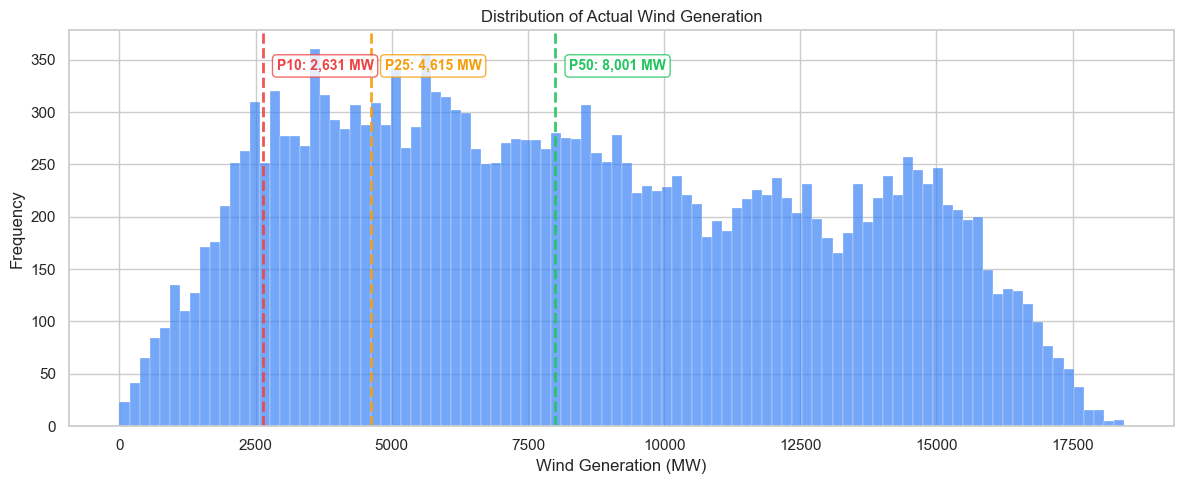

In [5]:
# ── 1b: Histogram with percentile markers ───────────────────

p10 = stats['P10']
p25 = stats['P25']
p50 = stats['P50']

fig, ax = plt.subplots(figsize=FIGURE_SIZE)

ax.hist(df['actual'], bins=HIST_BINS, color=C_ACTUAL, alpha=0.7,
        edgecolor='white', linewidth=0.3)

# Percentile markers
for val, label, color in [(p10, 'P10', '#ef4444'), (p25, 'P25', '#f59e0b'), (p50, 'P50', '#22c55e')]:
    ax.axvline(val, color=color, linewidth=2, linestyle='--', alpha=0.9)
    ax.annotate(f'{label}: {val:,.0f} MW', xy=(val, ax.get_ylim()[1] * 0.9),
                xytext=(10, 0), textcoords='offset points',
                fontsize=10, fontweight='bold', color=color,
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor=color, alpha=0.8))

ax.set_xlabel('Wind Generation (MW)')
ax.set_ylabel('Frequency')
ax.set_title('Distribution of Actual Wind Generation')
plt.tight_layout()
fig.savefig(f'{FIGURE_DIR}/01_generation_histogram.png', dpi=150)
plt.show()

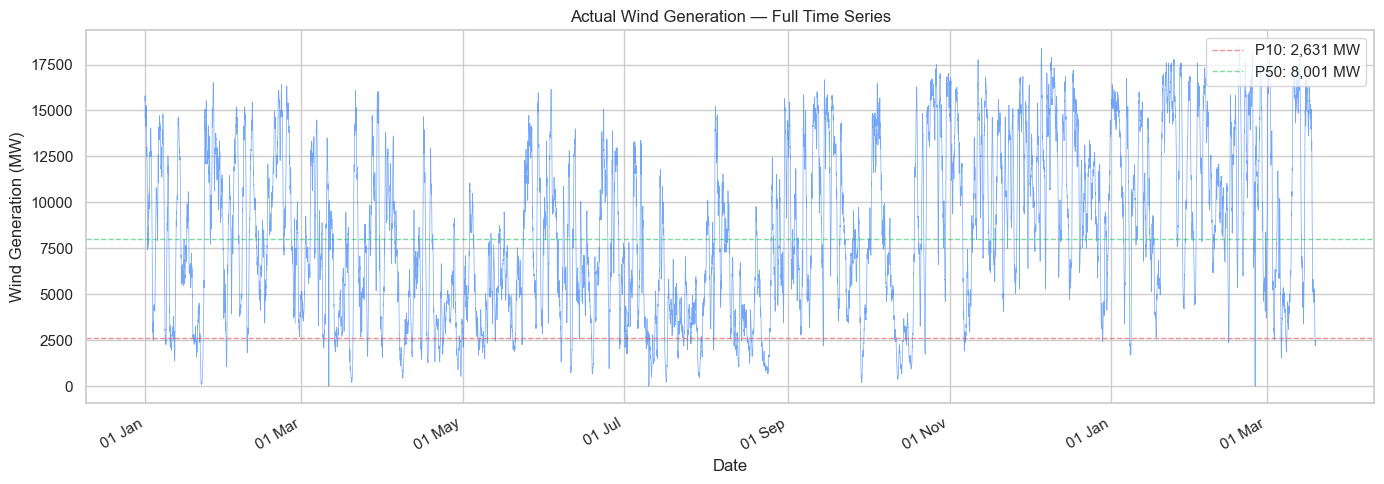

In [6]:
# ── 1c: Full time series of actual generation ────────────────

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(df['startTime'], df['actual'], linewidth=0.5, color=C_ACTUAL, alpha=0.7)
ax.axhline(p10, color='#ef4444', linewidth=1, linestyle='--', alpha=0.6, label=f'P10: {p10:,.0f} MW')
ax.axhline(p50, color='#22c55e', linewidth=1, linestyle='--', alpha=0.6, label=f'P50: {p50:,.0f} MW')

ax.set_xlabel('Date')
ax.set_ylabel('Wind Generation (MW)')
ax.set_title('Actual Wind Generation — Full Time Series')
ax.legend(loc='upper right')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
fig.autofmt_xdate(rotation=30)
plt.tight_layout()
fig.savefig(f'{FIGURE_DIR}/02_generation_timeseries.png', dpi=150)
plt.show()

### Interpretation

_[Your analysis of basic generation statistics]_

---
## Section 2 — Percentile Deep Dive (Reliability Curve)

In [7]:
# ── 2a: Compute P1 through P99 ───────────────────────────────

percentiles = np.arange(1, 100)
pct_values = np.percentile(df['actual'], percentiles)

# Exceedance probability: P(X >= threshold) = 1 - percentile/100
# E.g., P10 value → 90% of time generation exceeds this
exceedance_prob = (100 - percentiles) / 100

# Key reliability levels
p10_val = np.percentile(df['actual'], 10)   # 90% reliable
p25_val = np.percentile(df['actual'], 25)   # 75% reliable
p50_val = np.percentile(df['actual'], 50)   # 50% reliable

print(f'There is a 90% chance wind generation exceeds {p10_val:,.0f} MW')
print(f'There is a 75% chance wind generation exceeds {p25_val:,.0f} MW')
print(f'There is a 50% chance wind generation exceeds {p50_val:,.0f} MW')

There is a 90% chance wind generation exceeds 2,631 MW
There is a 75% chance wind generation exceeds 4,615 MW
There is a 50% chance wind generation exceeds 8,001 MW


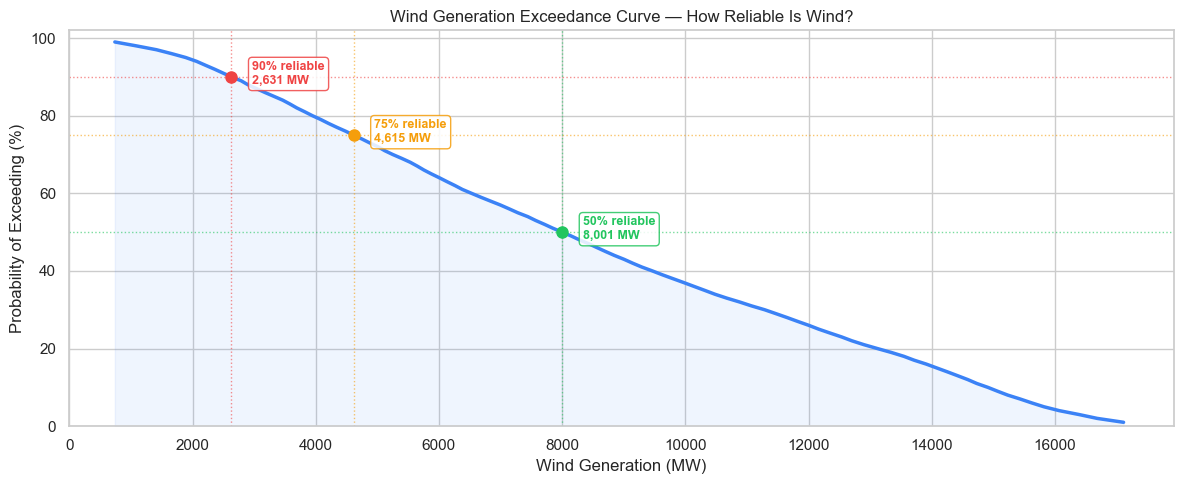

In [8]:
# ── 2b: Exceedance curve (CDF) ───────────────────────────────

fig, ax = plt.subplots(figsize=FIGURE_SIZE)

ax.plot(pct_values, exceedance_prob * 100, linewidth=2.5, color=C_ACTUAL)
ax.fill_between(pct_values, 0, exceedance_prob * 100, alpha=0.08, color=C_ACTUAL)

# Mark key reliability levels
markers = [
    (p10_val, 90, '90% reliable', '#ef4444'),
    (p25_val, 75, '75% reliable', '#f59e0b'),
    (p50_val, 50, '50% reliable', '#22c55e'),
]

for mw, pct, label, color in markers:
    ax.axhline(pct, color=color, linestyle=':', linewidth=1, alpha=0.6)
    ax.axvline(mw, color=color, linestyle=':', linewidth=1, alpha=0.6)
    ax.plot(mw, pct, 'o', color=color, markersize=8, zorder=5)
    ax.annotate(f'{label}\n{mw:,.0f} MW',
                xy=(mw, pct), xytext=(15, -5), textcoords='offset points',
                fontsize=9, fontweight='bold', color=color,
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor=color, alpha=0.85))

ax.set_xlabel('Wind Generation (MW)')
ax.set_ylabel('Probability of Exceeding (%)' )
ax.set_title('Wind Generation Exceedance Curve — How Reliable Is Wind?')
ax.set_ylim(0, 102)
ax.set_xlim(left=0)
plt.tight_layout()
fig.savefig(f'{FIGURE_DIR}/03_exceedance_curve.png', dpi=150)
plt.show()

### Interpretation & Recommendation

_[Your recommendation on reliable MW planning floor goes here]_

---
## Section 3 — Seasonal Variation

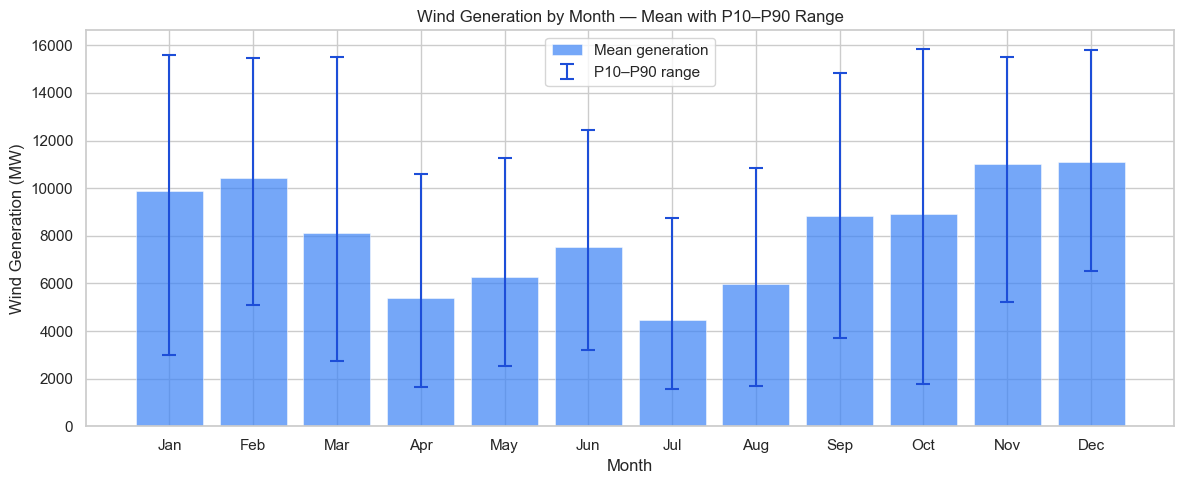

In [9]:
# ── 3a: Monthly mean, P10, P90 ───────────────────────────────

df['month'] = df['startTime'].dt.month
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

monthly = df.groupby('month')['actual'].agg(
    mean='mean',
    p10=lambda x: x.quantile(0.10),
    p90=lambda x: x.quantile(0.90),
)

fig, ax = plt.subplots(figsize=FIGURE_SIZE)

x = monthly.index
ax.bar(x, monthly['mean'], color=C_ACTUAL, alpha=0.7, edgecolor='white',
       linewidth=0.5, label='Mean generation')

# Error bars showing P10–P90 range
ax.errorbar(x, monthly['mean'],
            yerr=[monthly['mean'] - monthly['p10'], monthly['p90'] - monthly['mean']],
            fmt='none', ecolor='#1d4ed8', capsize=5, capthick=1.5, linewidth=1.5,
            label='P10–P90 range')

ax.set_xlabel('Month')
ax.set_ylabel('Wind Generation (MW)')
ax.set_title('Wind Generation by Month — Mean with P10–P90 Range')
ax.set_xticks(x)
ax.set_xticklabels([month_names[m-1] for m in x])
ax.legend()
plt.tight_layout()
fig.savefig(f'{FIGURE_DIR}/04_monthly_generation.png', dpi=150)
plt.show()

### Interpretation

_[Your analysis of seasonal patterns]_

---
## Section 4 — Time of Day Profile

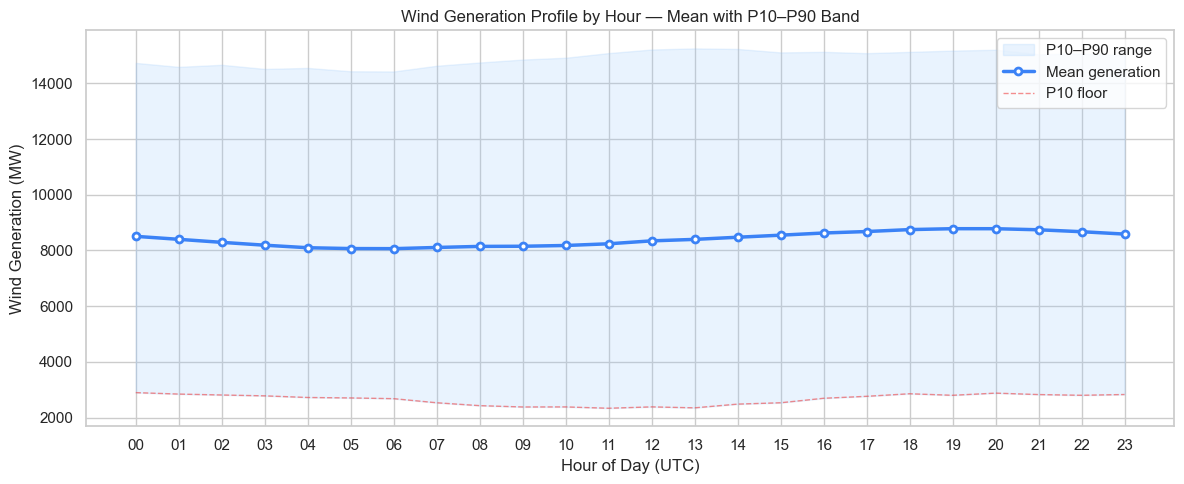

In [10]:
# ── 4a: Hourly profile with P10-P90 band ─────────────────────

df['hour'] = df['startTime'].dt.hour

hourly = df.groupby('hour')['actual'].agg(
    mean='mean',
    p10=lambda x: x.quantile(0.10),
    p90=lambda x: x.quantile(0.90),
)

fig, ax = plt.subplots(figsize=FIGURE_SIZE)

hours = hourly.index
ax.fill_between(hours, hourly['p10'], hourly['p90'],
                alpha=0.2, color=C_BAND, label='P10–P90 range')
ax.plot(hours, hourly['mean'], linewidth=2.5, color=C_ACTUAL,
        marker='o', markersize=5, markerfacecolor='white',
        markeredgecolor=C_ACTUAL, markeredgewidth=2, label='Mean generation')
ax.plot(hours, hourly['p10'], linewidth=1, color='#ef4444', linestyle='--',
        alpha=0.6, label=f'P10 floor')

ax.set_xlabel('Hour of Day (UTC)')
ax.set_ylabel('Wind Generation (MW)')
ax.set_title('Wind Generation Profile by Hour — Mean with P10–P90 Band')
ax.set_xticks(range(0, 24))
ax.set_xticklabels([f'{h:02d}' for h in range(24)])
ax.legend()
plt.tight_layout()
fig.savefig(f'{FIGURE_DIR}/05_hourly_profile.png', dpi=150)
plt.show()

### Interpretation

_[Your analysis of time-of-day generation patterns]_

---
## Section 5 — Low Generation Events (Worst Case Risk)

In [11]:
# ── 5a: Define low-wind events and find consecutive streaks ─

low_wind_threshold = p10_val  # Below P10 is "low wind"
print(f'Low-wind threshold (P10): {low_wind_threshold:,.0f} MW')

df['is_low'] = df['actual'] < low_wind_threshold

# Find consecutive streaks of low wind
# Create a group ID that changes each time is_low flips
df['streak_group'] = (df['is_low'] != df['is_low'].shift()).cumsum()

low_streaks = (
    df[df['is_low']]
    .groupby('streak_group')
    .agg(
        start=('startTime', 'first'),
        end=('startTime', 'last'),
        count=('startTime', 'size'),
        min_generation=('actual', 'min'),
        mean_generation=('actual', 'mean'),
    )
)

# Convert count (half-hour periods) to hours
low_streaks['duration_hours'] = low_streaks['count'] * (EXPECTED_RESOLUTION_MIN / 60)

max_streak = low_streaks['duration_hours'].max()
total_low_periods = df['is_low'].sum()
pct_low = 100 * total_low_periods / len(df)

print(f'\nTotal low-wind periods: {total_low_periods:,} ({pct_low:.1f}% of all periods)')
print(f'Number of distinct low-wind events: {len(low_streaks)}')
print(f'Max consecutive low-wind duration: {max_streak:.0f} hours')
print(f'\nTop 10 longest low-wind events:')
print(low_streaks.nlargest(10, 'duration_hours')[['start', 'end', 'duration_hours', 'min_generation']].to_string())

Low-wind threshold (P10): 2,631 MW

Total low-wind periods: 2,124 (10.0% of all periods)
Number of distinct low-wind events: 103
Max consecutive low-wind duration: 76 hours

Top 10 longest low-wind events:
                                 start                       end  duration_hours  min_generation
streak_group                                                                                    
166          2025-08-21 21:30:00+00:00 2025-08-25 01:00:00+00:00            76.0             659
176          2025-10-11 19:00:00+00:00 2025-10-14 11:30:00+00:00            65.0             391
56           2025-04-07 02:30:00+00:00 2025-04-09 02:30:00+00:00            48.5             425
184          2025-10-16 10:00:00+00:00 2025-10-18 01:30:00+00:00            40.0             933
142          2025-07-28 17:30:00+00:00 2025-07-30 04:30:00+00:00            35.5             462
48           2025-03-19 04:00:00+00:00 2025-03-20 14:00:00+00:00            34.5             197
170          2025-

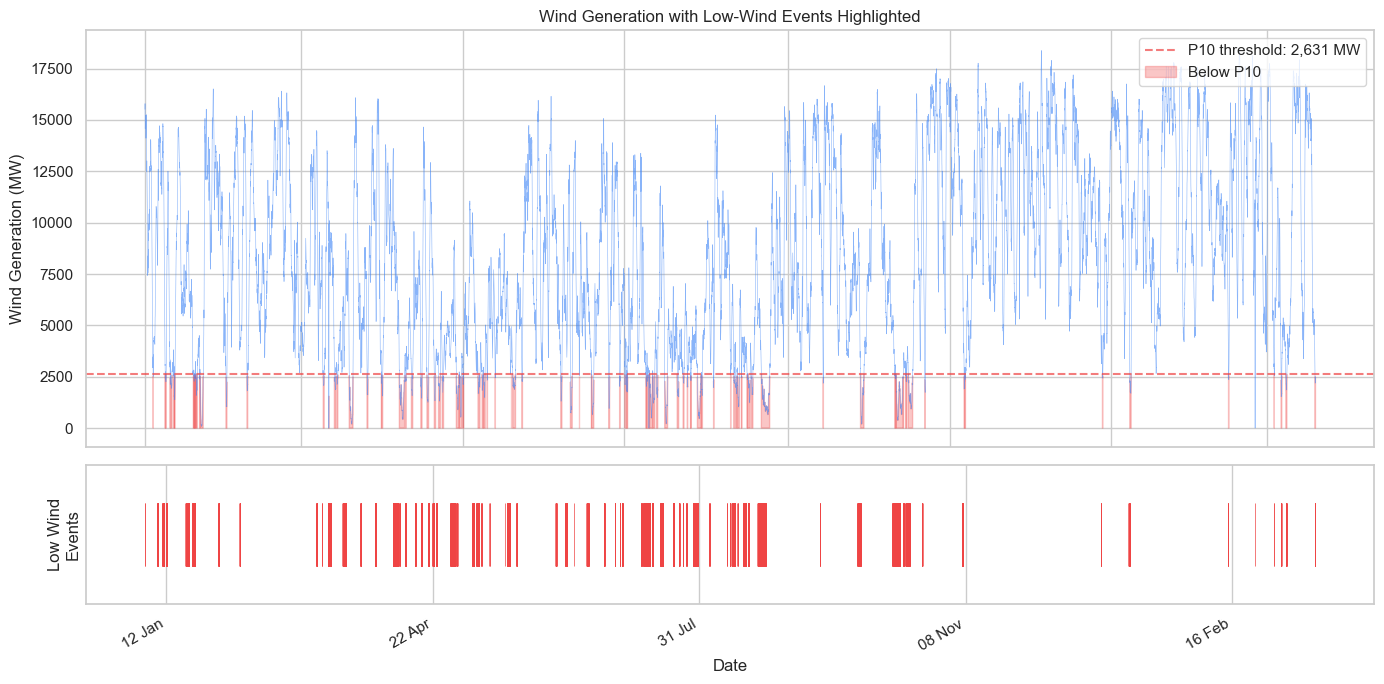

In [12]:
# ── 5b: Timeline rug plot of low-wind events ────────────────

fig, axes = plt.subplots(2, 1, figsize=(14, 7), gridspec_kw={'height_ratios': [3, 1]})

# Top: generation time series with low-wind shading
ax = axes[0]
ax.plot(df['startTime'], df['actual'], linewidth=0.4, color=C_ACTUAL, alpha=0.6)
ax.axhline(low_wind_threshold, color=C_LOW_WIND, linewidth=1.5, linestyle='--',
           alpha=0.7, label=f'P10 threshold: {low_wind_threshold:,.0f} MW')

# Shade low wind periods
low_mask = df['is_low'].values
ax.fill_between(df['startTime'], 0, df['actual'],
                where=low_mask, alpha=0.3, color=C_LOW_WIND, label='Below P10')

ax.set_ylabel('Wind Generation (MW)')
ax.set_title('Wind Generation with Low-Wind Events Highlighted')
ax.legend(loc='upper right')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))

# Bottom: rug plot of low-wind events
ax2 = axes[1]
low_times = df[df['is_low']]['startTime']
ax2.eventplot([mdates.date2num(t) for t in low_times],
              orientation='horizontal', colors=C_LOW_WIND, linewidths=0.5)
ax2.set_xlabel('Date')
ax2.set_ylabel('Low Wind\nEvents')
ax2.set_yticks([])
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))

fig.autofmt_xdate(rotation=30)
plt.tight_layout()
fig.savefig(f'{FIGURE_DIR}/06_low_wind_timeline.png', dpi=150)
plt.show()

### Interpretation

_[Your analysis of low-wind event risk and grid implications]_

---
## Section 6 — Recommendation Summary Table

In [13]:
# ── 6a: Auto-generate reliability recommendation table ───────

p1_val = np.percentile(df['actual'], 1)    # 99% reliable
p5_val = np.percentile(df['actual'], 5)    # 95% reliable

recommendation = pd.DataFrame({
    'Reliability Level': ['99% reliable', '90% reliable', '75% reliable', '50% reliable'],
    'MW Threshold': [f'{p1_val:,.0f} MW', f'{p10_val:,.0f} MW', f'{p25_val:,.0f} MW', f'{p50_val:,.0f} MW'],
    'Interpretation': [
        'Almost always available',
        'Conservative planning floor',
        'Moderate confidence',
        'Expected average floor'
    ]
})

print('=== Wind Power Reliability — Recommendation Table ===')
print(recommendation.to_string(index=False))
print()
print(f'Based on {len(df):,} half-hour observations from {df["startTime"].min().date()} to {df["startTime"].max().date()}')

=== Wind Power Reliability — Recommendation Table ===
Reliability Level MW Threshold              Interpretation
     99% reliable       739 MW     Almost always available
     90% reliable     2,631 MW Conservative planning floor
     75% reliable     4,615 MW         Moderate confidence
     50% reliable     8,001 MW      Expected average floor

Based on 21,232 half-hour observations from 2024-12-31 to 2026-03-19


### Final Recommendation

_[Your final recommendation on reliable wind capacity for planning purposes goes here]_